# Compare KDE and ZIG calcium likelihoods

This notebook validates the new ZIG calcium likelihood against the existing KDE spike likelihood on the same simulated calcium pipeline.

Planned flow:
1. Simulate run and replay datasets.
2. Deconvolve calcium traces once with OASIS.
3. Decode with KDE and ZIG likelihoods.
4. Compare posteriors and decoding error.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr

from replay_trajectory_classification.calcium_sorted_spikes_decoding import (
    deconvolve_and_binarize,
    deconvolve_continuous,
    make_sorted_spikes_decoder,
    maximum_a_posteriori_position,
    median_decoding_error,
)
from replay_trajectory_classification.core import (
    _acausal_decode,
    _causal_decode,
    scaled_likelihood,
)
from replay_trajectory_classification.likelihoods.deconv_calcium_likelihood import (
    estimate_zig_likelihood,
    estimate_zig_place_fields,
)
from replay_trajectory_classification.likelihoods.spiking_likelihood_kde import (
    estimate_spiking_likelihood_kde,
)
from replay_trajectory_classification.simulate import simulate_position, simulate_time
from replay_trajectory_classification.simulate_calcium import (
    make_continuous_replay,
    make_simulated_run_data,
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_context("talk", font_scale=0.8)
np.random.seed(0)

Cupy is not installed or GPU is not detected. Ignore this message if not using GPU
/home/ericliu/anaconda3/envs/decoder/lib/python3.13/site-packages/replay_trajectory_classification/likelihoods/multiunit_likelihood.py:14: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm
/home/ericliu/anaconda3/envs/decoder/lib/python3.13/site-packages/oasis/functions.py:13: UserWarning: Could not find cvxpy. Don't worry, you can still use OASIS, just not the slower interior point methods we compared to in the papers.
  warn("Could not find cvxpy. Don't worry, you can still use OASIS, " +


In [2]:
TRACK_HEIGHT = 200.0
N_NEURONS = 20
PLACE_FIELD_MEANS = np.linspace(0.0, TRACK_HEIGHT, N_NEURONS)
RUN_SAMPLING_FREQUENCY = 30
REPLAY_SAMPLING_FREQUENCY = 200
INTERNAL_SAMPLING_FREQUENCY = 1000
N_RUNS = 2
BASE_SIGMA = 5.0
BASE_RUNNING_SPEED = 10.0
REPLAY_SPEEDUP = 120
POSITION_STD = 3.0
ZIG_N_EPOCHS = 2000

In [3]:
def deconvolve_oasis(calcium_traces):
    s_continuous = np.asarray(deconvolve_continuous(calcium_traces), dtype=float)
    s_binary = deconvolve_and_binarize(calcium_traces)
    return s_continuous, s_binary


def make_true_continuous_replay_position(
    replay_time,
    track_height=TRACK_HEIGHT,
    running_speed=BASE_RUNNING_SPEED,
    replay_speedup=REPLAY_SPEEDUP,
    is_outbound=True,
):
    replay_time = np.asarray(replay_time, dtype=float)
    replay_speed = running_speed * replay_speedup
    if is_outbound:
        return np.minimum(replay_speed * replay_time, track_height)
    return np.maximum(track_height - replay_speed * replay_time, 0.0)


def make_run_dataset(rng_seed, sigma=BASE_SIGMA, running_speed=BASE_RUNNING_SPEED):
    time, position, sampling_frequency, calcium_traces, true_spikes, place_fields = make_simulated_run_data(
        sampling_frequency=RUN_SAMPLING_FREQUENCY,
        track_height=TRACK_HEIGHT,
        running_speed=running_speed,
        n_runs=N_RUNS,
        place_field_means=PLACE_FIELD_MEANS,
        sigma=sigma,
        rng=np.random.default_rng(rng_seed),
    )
    s_continuous, s_binary = deconvolve_oasis(calcium_traces)
    return {
        "time": time,
        "position": position,
        "sampling_frequency": sampling_frequency,
        "calcium_traces": calcium_traces,
        "true_spikes": true_spikes,
        "place_fields": place_fields,
        "s_continuous": s_continuous,
        "s_binary": s_binary,
        "sigma": sigma,
        "running_speed": running_speed,
    }


def make_replay_dataset(rng_seed, sigma=BASE_SIGMA, running_speed=BASE_RUNNING_SPEED):
    time, true_spikes, calcium_traces = make_continuous_replay(
        sampling_frequency=REPLAY_SAMPLING_FREQUENCY,
        internal_sampling_frequency=INTERNAL_SAMPLING_FREQUENCY,
        track_height=TRACK_HEIGHT,
        running_speed=running_speed,
        place_field_means=PLACE_FIELD_MEANS,
        replay_speedup=REPLAY_SPEEDUP,
        sigma=sigma,
        rng=np.random.default_rng(rng_seed),
    )
    true_position = make_true_continuous_replay_position(time, running_speed=running_speed)
    assert true_position.shape == time.shape, "Replay position must align with replay time bins"
    s_continuous, s_binary = deconvolve_oasis(calcium_traces)
    return {
        "time": time,
        "position": true_position,
        "sampling_frequency": REPLAY_SAMPLING_FREQUENCY,
        "calcium_traces": calcium_traces,
        "true_spikes": true_spikes,
        "s_continuous": s_continuous,
        "s_binary": s_binary,
        "sigma": sigma,
        "running_speed": running_speed,
    }


def fit_shared_decoder(train_dataset):
    decoder = make_sorted_spikes_decoder(
        position=train_dataset["position"],
        sampling_frequency=train_dataset["sampling_frequency"],
        position_std=POSITION_STD,
    )
    decoder.fit(train_dataset["position"], train_dataset["s_binary"])
    return decoder


def build_posteriors(log_likelihood, decoder, time):
    time = np.asarray(time)
    is_track_interior = decoder.environment.is_track_interior_.ravel(order="F")
    n_time = time.shape[0]
    n_position_bins = is_track_interior.shape[0]
    st_interior_ind = np.ix_(is_track_interior, is_track_interior)
    likelihood = scaled_likelihood(np.asarray(log_likelihood, dtype=float))

    causal_posterior = np.full((n_time, n_position_bins), np.nan, dtype=float)
    causal_posterior[:, is_track_interior], data_log_likelihood = _causal_decode(
        decoder.initial_conditions_[is_track_interior].astype(float),
        decoder.state_transition_[st_interior_ind].astype(float),
        likelihood[:, is_track_interior].astype(float),
    )

    acausal_posterior = np.full((n_time, n_position_bins, 1), np.nan, dtype=float)
    acausal_posterior[:, is_track_interior] = _acausal_decode(
        causal_posterior[:, is_track_interior, np.newaxis].astype(float),
        decoder.state_transition_[st_interior_ind].astype(float),
    )

    position = decoder.environment.place_bin_centers_.squeeze()
    return {
        "likelihood": xr.DataArray(likelihood, coords={"time": time, "position": position}, dims=["time", "position"]),
        "causal_posterior": xr.DataArray(causal_posterior, coords={"time": time, "position": position}, dims=["time", "position"]),
        "acausal_posterior": xr.DataArray(acausal_posterior.squeeze(-1), coords={"time": time, "position": position}, dims=["time", "position"]),
        "data_log_likelihood": float(data_log_likelihood),
    }

## Shared deconvolution check

In [4]:
run_a = make_run_dataset(rng_seed=0)
run_b = make_run_dataset(rng_seed=1)
replay_b = make_replay_dataset(rng_seed=2)

pd.DataFrame(
    [
        {
            "dataset": "run_a",
            "n_time": len(run_a["time"]),
            "s_continuous_shape": run_a["s_continuous"].shape,
            "s_binary_shape": run_a["s_binary"].shape,
            "binary_spike_fraction": float(run_a["s_binary"].mean()),
        },
        {
            "dataset": "run_b",
            "n_time": len(run_b["time"]),
            "s_continuous_shape": run_b["s_continuous"].shape,
            "s_binary_shape": run_b["s_binary"].shape,
            "binary_spike_fraction": float(run_b["s_binary"].mean()),
        },
        {
            "dataset": "replay_b",
            "n_time": len(replay_b["time"]),
            "s_continuous_shape": replay_b["s_continuous"].shape,
            "s_binary_shape": replay_b["s_binary"].shape,
            "binary_spike_fraction": float(replay_b["s_binary"].mean()),
        },
    ]
)

/home/ericliu/anaconda3/envs/decoder/lib/python3.13/site-packages/oasis/functions.py:849: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 200, using nperseg = 200
  ff, Pxx = scipy.signal.welch(y)


,dataset,n_time,s_continuous_shape,s_binary_shape,binary_spike_fraction
0,run_a,2424,"(2424, 20)","(2424, 20)",0.014171
1,run_b,2424,"(2424, 20)","(2424, 20)",0.014171
2,replay_b,200,"(200, 20)","(200, 20)",0.088750


## KDE path

In [5]:
def decode_with_kde(decoder, dataset):
    log_likelihood = estimate_spiking_likelihood_kde(
        dataset["s_binary"],
        np.asarray(decoder.place_fields_),
        is_track_interior=decoder.environment.is_track_interior_,
    )
    return build_posteriors(log_likelihood, decoder, dataset["time"])


shared_decoder = fit_shared_decoder(run_a)
kde_run_b_results = decode_with_kde(shared_decoder, run_b)
kde_replay_b_results = decode_with_kde(shared_decoder, replay_b)

kde_summary = pd.DataFrame(
    [
        {
            "dataset": "run_b",
            "median_abs_error": median_decoding_error(kde_run_b_results["acausal_posterior"], run_b["position"]),
            "data_log_likelihood": kde_run_b_results["data_log_likelihood"],
        },
        {
            "dataset": "replay_b",
            "median_abs_error": median_decoding_error(kde_replay_b_results["acausal_posterior"], replay_b["position"]),
            "data_log_likelihood": kde_replay_b_results["data_log_likelihood"],
        },
    ]
)
kde_summary

/home/ericliu/anaconda3/envs/decoder/lib/python3.13/site-packages/replay_trajectory_classification/likelihoods/spiking_likelihood_kde.py:148: RuntimeWarning: divide by zero encountered in log
  return np.exp(np.log(mean_rate) + np.log(marginal_density) - np.log(occupancy))
100%|██████████| 20/20 [00:00<00:00, 1540.18it/s]
/home/ericliu/anaconda3/envs/decoder/lib/python3.13/site-packages/replay_trajectory_classification/core.py:103: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'F', False, aligned=True), Array(float64, 1, 'A', False, aligned=True))
  posterior[k] = state_transition.T @ posterior[k - 1] * likelihood[k]
/home/ericliu/anaconda3/envs/decoder/lib/python3.13/site-packages/replay_trajectory_classification/core.py:138: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'F', False, aligned=True), Array(float64, 2, 'A', False, aligned=True))
  acausal_prior = state_transition.T @ causal_posterior[t

,dataset,median_abs_error,data_log_likelihood
0,run_b,3.543201,-2274.485370
1,replay_b,49.000004,-1831.600591


## ZIG path

In [6]:
zig_place_fields, zig_k_values = estimate_zig_place_fields(
    run_a["position"],
    run_a["s_continuous"],
    place_bin_centers=shared_decoder.environment.place_bin_centers_,
    place_bin_edges=shared_decoder.environment.place_bin_edges_,
    n_epochs=ZIG_N_EPOCHS,
)

def decode_with_zig(decoder, dataset, zig_place_fields, zig_k_values):
    log_likelihood = estimate_zig_likelihood(
        dataset["s_continuous"],
        zig_place_fields,
        zig_k_values,
        is_track_interior=decoder.environment.is_track_interior_,
    )
    return build_posteriors(log_likelihood, decoder, dataset["time"])


zig_run_b_results = decode_with_zig(shared_decoder, run_b, zig_place_fields, zig_k_values)
zig_replay_b_results = decode_with_zig(shared_decoder, replay_b, zig_place_fields, zig_k_values)

zig_summary = pd.DataFrame(
    [
        {
            "dataset": "run_b",
            "median_abs_error": median_decoding_error(zig_run_b_results["acausal_posterior"], run_b["position"]),
            "data_log_likelihood": zig_run_b_results["data_log_likelihood"],
        },
        {
            "dataset": "replay_b",
            "median_abs_error": median_decoding_error(zig_replay_b_results["acausal_posterior"], replay_b["position"]),
            "data_log_likelihood": zig_replay_b_results["data_log_likelihood"],
        },
    ]
)
zig_summary

,dataset,median_abs_error,data_log_likelihood
0,run_b,2.75087,-1146.753517
1,replay_b,59.00000,-2109.206753


## Comparison figures and summary

In [7]:
def plot_posterior_panel(ax, dataset, results, title):
    results["acausal_posterior"].plot(
        x="time",
        y="position",
        ax=ax,
        cmap="bone_r",
        add_colorbar=False,
    )
    ax.plot(dataset["time"], dataset["position"], color="magenta", linestyle="--", linewidth=2, label="True")
    ax.plot(
        dataset["time"],
        maximum_a_posteriori_position(results["acausal_posterior"]),
        color="cyan",
        linewidth=1.5,
        alpha=0.9,
        label="MAP",
    )
    ax.set_title(title)
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Position")


comparison_summary = pd.concat(
    [kde_summary.assign(method="KDE"), zig_summary.assign(method="ZIG")],
    ignore_index=True,
)[["method", "dataset", "median_abs_error", "data_log_likelihood"]]
comparison_summary

,method,dataset,median_abs_error,data_log_likelihood
0,KDE,run_b,3.543201,-2274.485370
1,KDE,replay_b,49.000004,-1831.600591
2,ZIG,run_b,2.750870,-1146.753517
3,ZIG,replay_b,59.000000,-2109.206753


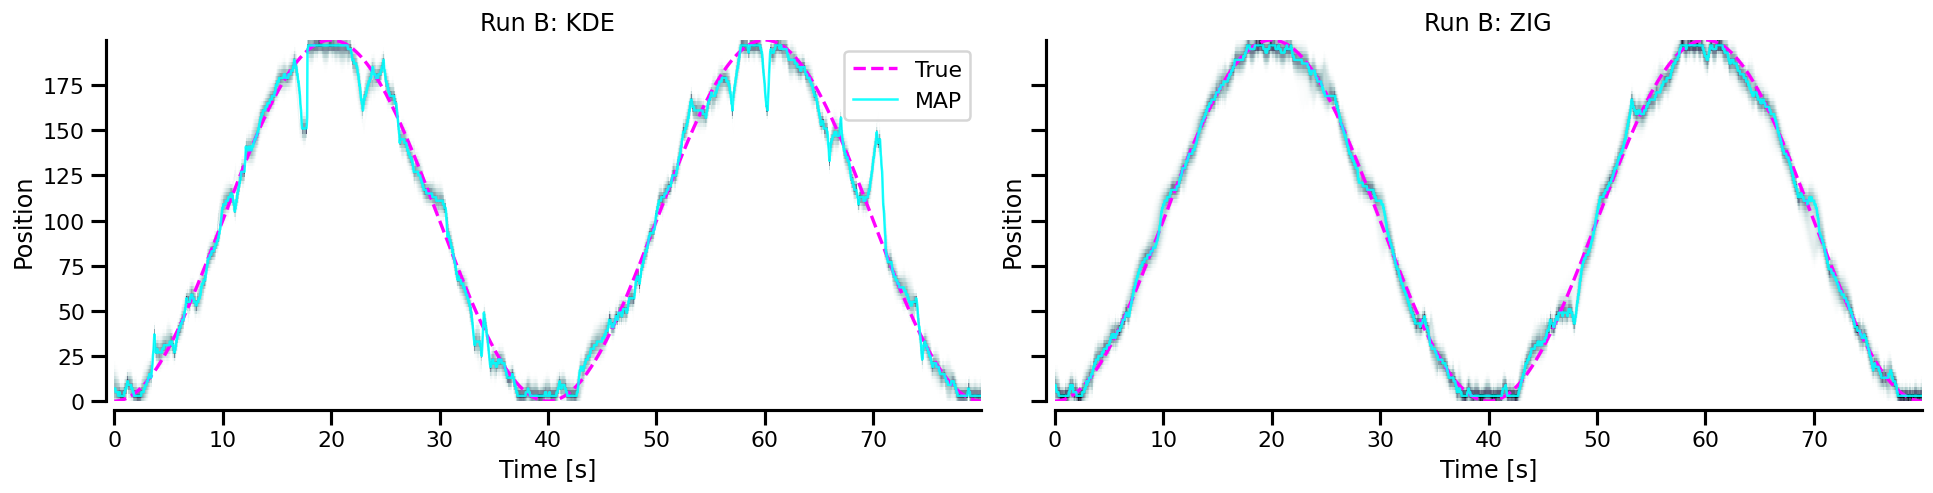

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True, constrained_layout=True)
plot_posterior_panel(axes[0], run_b, kde_run_b_results, "Run B: KDE")
plot_posterior_panel(axes[1], run_b, zig_run_b_results, "Run B: ZIG")
axes[0].legend(loc="upper right")
sns.despine(offset=5)

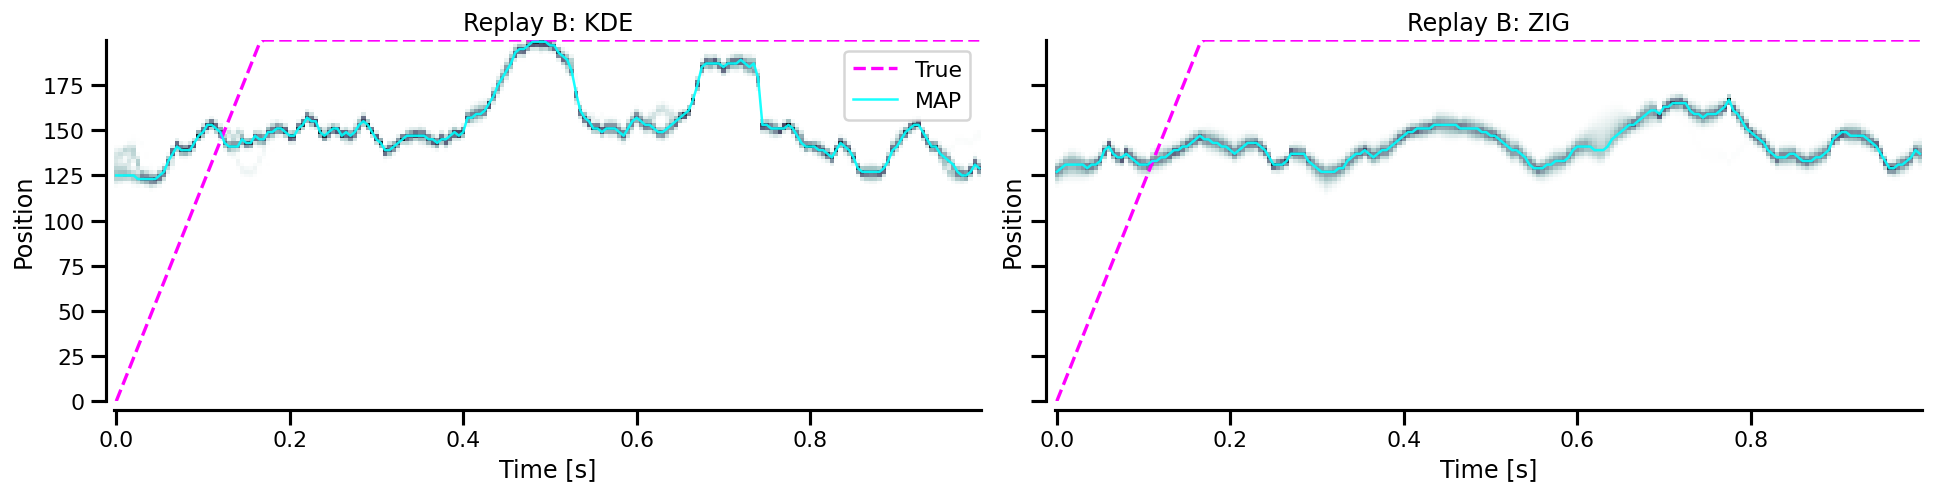

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True, constrained_layout=True)
plot_posterior_panel(axes[0], replay_b, kde_replay_b_results, "Replay B: KDE")
plot_posterior_panel(axes[1], replay_b, zig_replay_b_results, "Replay B: ZIG")
axes[0].legend(loc="upper right")
sns.despine(offset=5)